# 3.3 Identifiability

3.3 Identifiability: transform D (sky-dominated crop, true transform has
4 segments). Input histogram with support threshold marked, fit restricted
to trusted levels, and an explicit statement of the unconstrained range.

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
sys.path.insert(0, str(Path.cwd()))
from starter import transfer_curve, fit_piecewise, apply_recovered, support_report

ROOT = Path.cwd().parents[1]

In [4]:
d_in = np.asarray(Image.open(ROOT / "images/p3/field_skycrop_in.png"))
d_out = np.asarray(Image.open(ROOT / "images/p3/field_skycrop_out_D.png"))

T, cnt = transfer_curve(d_in, d_out)
MIN_COUNT = 20
report = support_report(cnt, min_count=MIN_COUNT)

In [5]:
print(f"Input crop: {d_in.shape}, {d_in.size} pixels")
print(f"Sampled input level range: [{np.where(cnt>0)[0].min()}, {np.where(cnt>0)[0].max()}]")
print(f"Support threshold (min_count) = {MIN_COUNT}")
print(f"Unsupported (cnt=0) ranges: {report['unsupported_ranges']}")
print(f"Trusted (cnt>={MIN_COUNT}) ranges: {report['trusted_ranges']}")
print(f"n unsupported={report['n_unsupported']}  n weak={report['n_weak']}  "
      f"n trusted={report['n_trusted']}")

Input crop: (200, 200), 40000 pixels
Sampled input level range: [0, 246]
Support threshold (min_count) = 20
Unsupported (cnt=0) ranges: [(208, 209), (218, 218), (224, 224), (229, 229), (240, 240), (242, 243), (247, 255)]
Trusted (cnt>=20) ranges: [(1, 58), (60, 60), (63, 64), (69, 69), (75, 75)]
n unsupported=17  n weak=176  n trusted=63


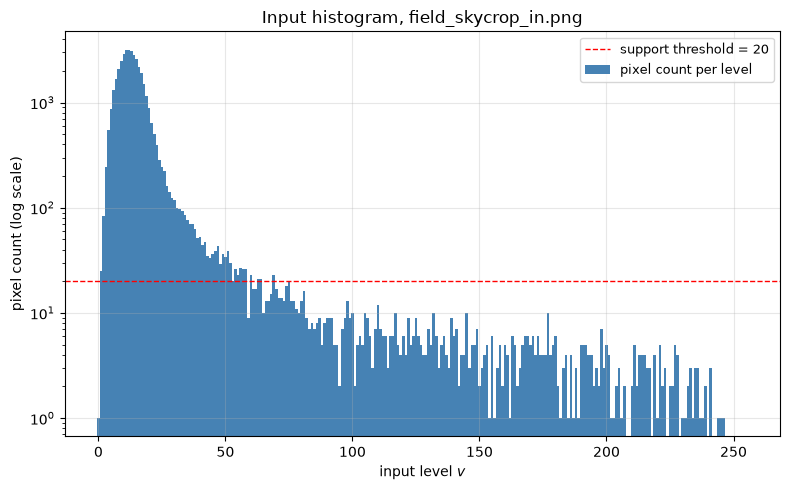

In [6]:
# --- (a) input histogram with threshold marked ---------------------------
fig, ax = plt.subplots(figsize=(8, 5))
levels = np.arange(256)
ax.bar(levels, cnt, width=1.0, color="steelblue", label="pixel count per level")
ax.axhline(MIN_COUNT, color="red", linestyle="--", linewidth=1,
           label=f"support threshold = {MIN_COUNT}")
ax.set_yscale("log")
ax.set_xlabel("input level $v$")
ax.set_ylabel("pixel count (log scale)")
ax.set_title("Input histogram, field_skycrop_in.png")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [7]:
# --- (b) fit restricted to trusted levels only ----------------------------
trusted_mask = np.zeros(256, dtype=bool)
for lo, hi in report["trusted_ranges"]:
    trusted_mask[lo:hi + 1] = True
cnt_trusted = np.where(trusted_mask, cnt, 0)

In [8]:
bps, slopes, inter, k = fit_piecewise(T, cnt_trusted, max_seg=4)
trusted_lo = min(lo for lo, hi in report["trusted_ranges"])
trusted_hi = max(hi for lo, hi in report["trusted_ranges"])
print(f"\nFit restricted to trusted levels [{trusted_lo},{trusted_hi}]: "
      f"k={k}  breakpoints={bps}  slopes={np.round(slopes, 4)}")
print(f"(c) reported {k} segments, not the true 4: levels above {trusted_hi} are "
      f"unidentifiable from this crop (see below)")


Fit restricted to trusted levels [1,75]: k=3  breakpoints=[ 1 21 56 75]  slopes=[1.5038 4.8627 0.3297]
(c) reported 3 segments, not the true 4: levels above 75 are unidentifiable from this crop (see below)


In [9]:
# Also show what a naive fit on ALL supported (not just trusted) levels gives,
# for contrast -- this is the wrong answer the identifiability check prevents.
bps_naive, slopes_naive, inter_naive, k_naive = fit_piecewise(T, cnt, max_seg=6)
print(f"\n(contrast) naive fit using ALL supported levels (ignoring weak support): "
      f"k={k_naive}  breakpoints={bps_naive}  slopes={np.round(slopes_naive, 4)}")


(contrast) naive fit using ALL supported levels (ignoring weak support): k=4  breakpoints=[  0  21  56 177 246]  slopes=[1.5    4.8627 0.3202 0.2009]


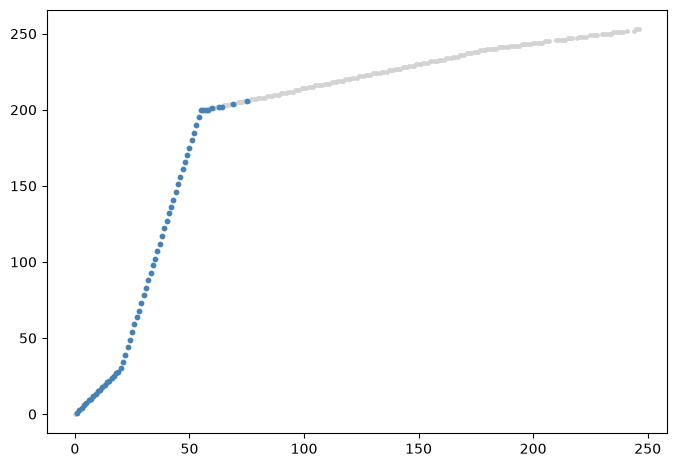

In [10]:
# --- scatter + fit, trusted vs full range, coloured by support -----------
fig, ax = plt.subplots(figsize=(8, 5.5))
supported = cnt > 0
vs_all = np.where(supported)[0]
weak_mask_arr = (cnt > 0) & (cnt < MIN_COUNT)
ax.scatter(np.where(trusted_mask)[0], T[trusted_mask], s=10, color="steelblue",
           label=f"trusted ($cnt\\geq{MIN_COUNT}$)", zorder=3)
ax.scatter(np.where(weak_mask_arr)[0], T[weak_mask_arr], s=6, color="lightgray",
           label=f"weak ($0<cnt<{MIN_COUNT}$)", zorder=2)

In [11]:
lut_v = np.arange(trusted_lo, trusted_hi + 1)
lut = np.zeros(len(lut_v))
for i, v in enumerate(lut_v):
    seg = min(max(np.searchsorted(bps, v, side="right") - 1, 0), len(slopes) - 1)
    lut[i] = slopes[seg] * v + inter[seg]
ax.plot(lut_v, lut, color="red", linewidth=2, label=f"fitted ($k$={k}), trusted range only", zorder=4)
ax.axvspan(trusted_hi, 255, color="red", alpha=0.08, label="unconstrained by this crop")
for bp in bps:
    ax.axvline(bp, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel("input level $v$")
ax.set_ylabel("$T[v]$")
ax.set_title(f"Transform D: fit restricted to well-supported levels $[{trusted_lo},{trusted_hi}]$")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()